**Bivariate Analysis**

In [ ]:
import pandas as pd
data=pd.read_csv("/content/AmazonCleanedData_Process1.csv")
df=pd.DataFrame(data)
df.head()


,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,Root (Department),Category,Sub_category,Sub-sub_category,Product_type
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,64,4.2,24269.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,43,4.0,43994.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,199.0,1899.0,90,3.9,7928.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,329.0,699.0,53,4.2,94363.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,154.0,399.0,61,4.2,16905.0,Computers & Accessories,Accessories & Peripherals,Cables & Accessories,Cables,USBCables


In [ ]:
df.columns

Index(['product_id', 'product_name', 'discounted_price', 'actual_price',
       'discount_percentage', 'rating', 'rating_count', 'Root (Department)',
       'Category', 'Sub_category', 'Sub-sub_category', 'Product_type'],
      dtype='object')

**Non- Parametric method:** Does not assume normal distrbution has no fixed formula, it works when data is skewed and has outliers

(Do not assume specific shape or formula it let data to speak)

Correlation: Spearman correlation matrices

Hypothesis testing: Mann-Whitney

Any pattern (Unknown)- Non-Parametric

**Spearman Correlation Matrix**

Since the data contained skewness and outliers, Spearman correlation was used because it is based on ranked values and is more robust to non-normal distributions compared to Pearson correlation.

In [ ]:
import pandas as pd

# Only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64'])

print(num_cols.columns)

# Spearman correlation matrix
corr_matrix = num_cols.corr(method='spearman')

print(corr_matrix)

Index(['discounted_price', 'actual_price', 'discount_percentage', 'rating',
       'rating_count'],
      dtype='object')
                     discounted_price  actual_price  discount_percentage  \
discounted_price             1.000000      0.932800            -0.375209   
actual_price                 0.932800      1.000000            -0.068496   
discount_percentage         -0.375209     -0.068496             1.000000   
rating                       0.082432      0.035403            -0.146103   
rating_count                 0.123942      0.095380            -0.095732   

                       rating  rating_count  
discounted_price     0.082432      0.123942  
actual_price         0.035403      0.095380  
discount_percentage -0.146103     -0.095732  
rating               1.000000      0.181038  
rating_count         0.181038      1.000000  


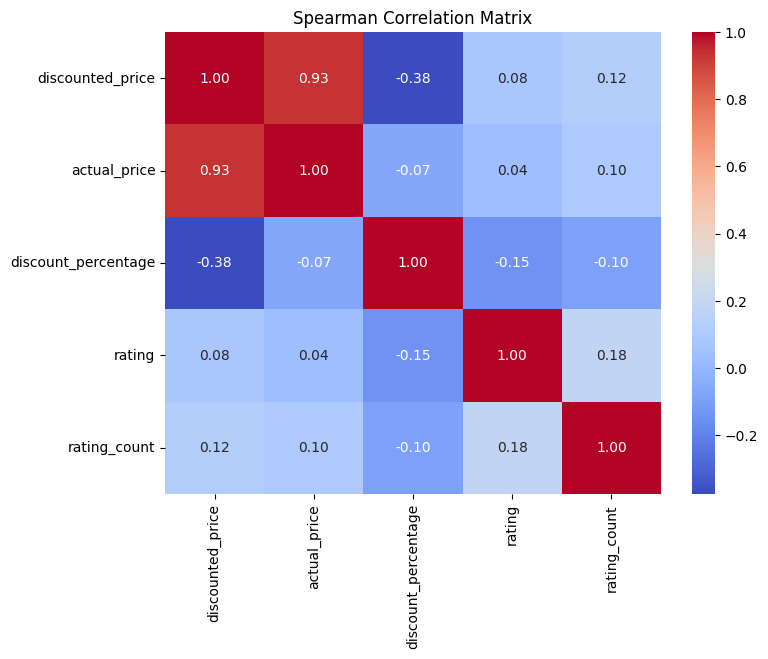

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Spearman Correlation Matrix")
plt.show()

**Parametric method:** Data follows specific distribution and summes fixed mathematical formula and number of parameters.

(Assume specific shape or formula before analysis)

Correlation: Pearson correlation matrices

Hypothesis testing: t-test

Rgression- Parametric

**Pearson Correlation**

In [ ]:
import pandas as pd

# Only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64'])

print(num_cols.columns)

# Spearman correlation matrix
corr_matrix = num_cols.corr(method='pearson')

print(corr_matrix)

Index(['discounted_price', 'actual_price', 'discount_percentage', 'rating',
       'rating_count'],
      dtype='object')
                     discounted_price  actual_price  discount_percentage  \
discounted_price             1.000000      0.961896            -0.243469   
actual_price                 0.961896      1.000000            -0.118973   
discount_percentage         -0.243469     -0.118973             1.000000   
rating                       0.120668      0.121999            -0.155507   
rating_count                -0.027084     -0.036003             0.010848   

                       rating  rating_count  
discounted_price     0.120668     -0.027084  
actual_price         0.121999     -0.036003  
discount_percentage -0.155507      0.010848  
rating               1.000000      0.102016  
rating_count         0.102016      1.000000  


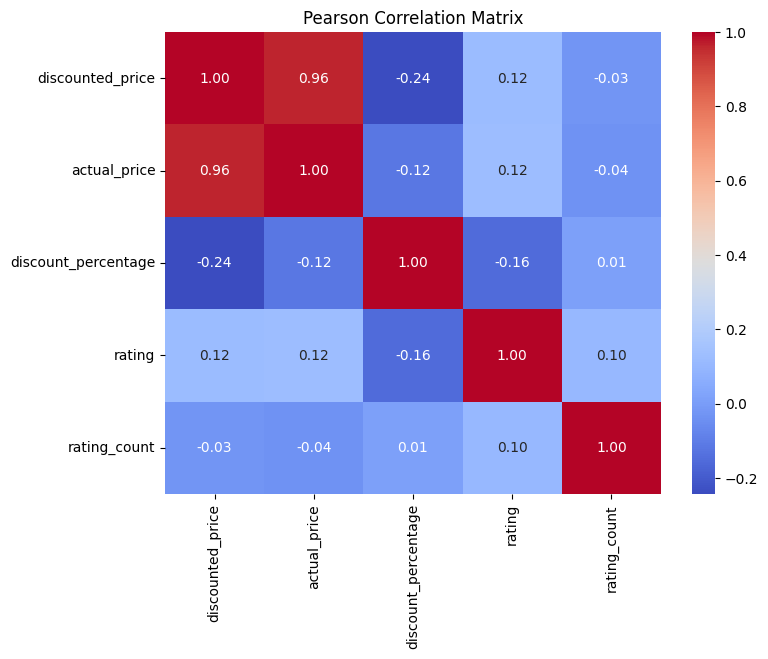

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Pearson Correlation Matrix")
plt.show()

**Transformation**

A log transformation is applied to reduce skewness and minimise the impact of extreme values (on the temporary basis), allowing clearer interpretation of the relationship.

In [ ]:
import numpy as np

# Transformation (Temporary basis )
df['log_discounted_price'] = np.log1p(df['discounted_price'])
df['log_actual_price'] = np.log1p(df['actual_price'])
df['log_rating_count'] = np.log1p(df['rating_count'])

df.columns

Index(['product_id', 'product_name', 'discounted_price', 'actual_price',
       'discount_percentage', 'rating', 'rating_count', 'Root (Department)',
       'Category', 'Sub_category', 'Sub-sub_category', 'Product_type',
       'log_discounted_price', 'log_actual_price', 'log_rating_count'],
      dtype='object')

Before and after transformation

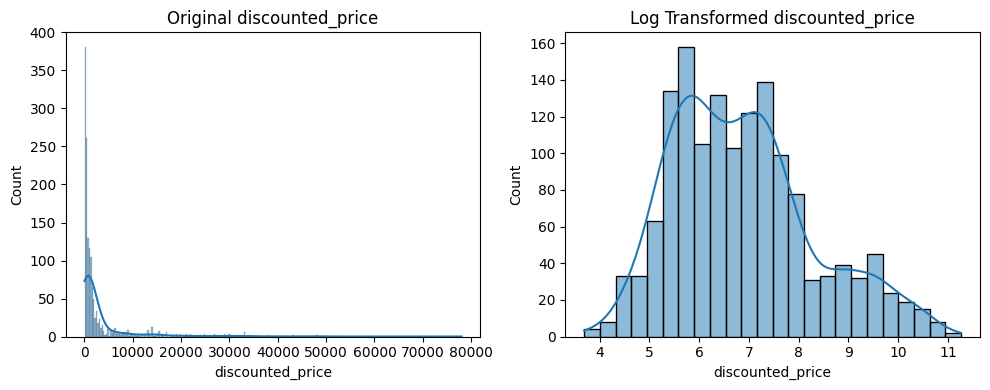

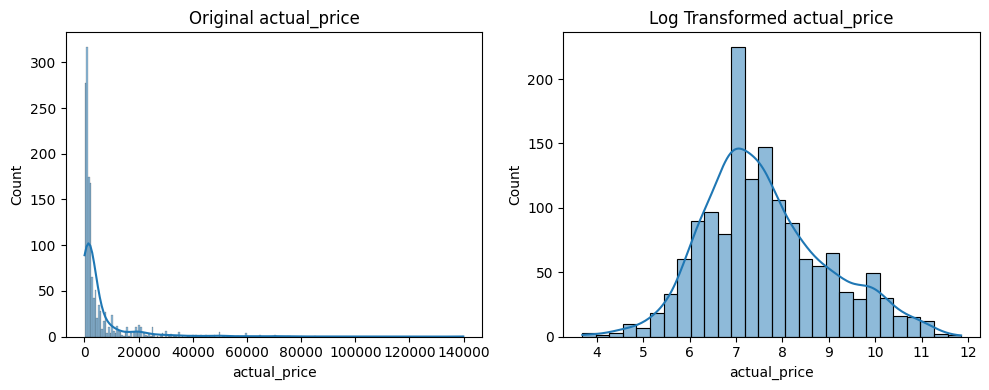

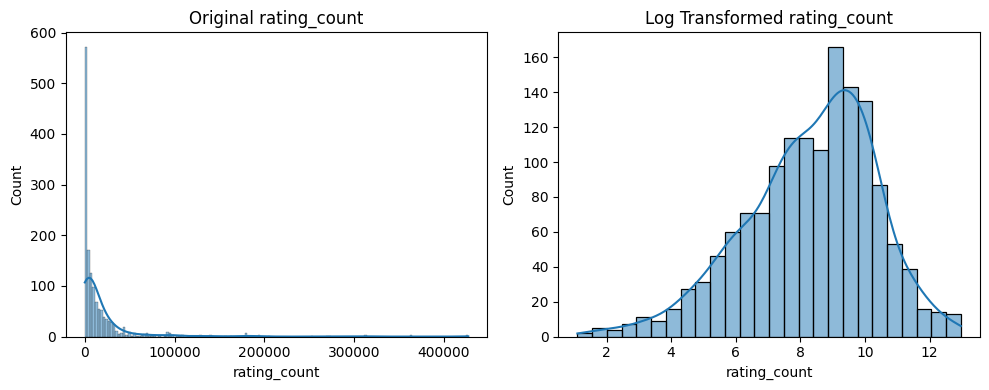

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['discounted_price', 'actual_price', 'rating_count']

for col in cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Original {col}')

    plt.subplot(1,2,2)
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f'Log Transformed {col}')

    plt.tight_layout()
    plt.show()

**Experiments**
1. Discounted prics vs Ratings

Before Transformation

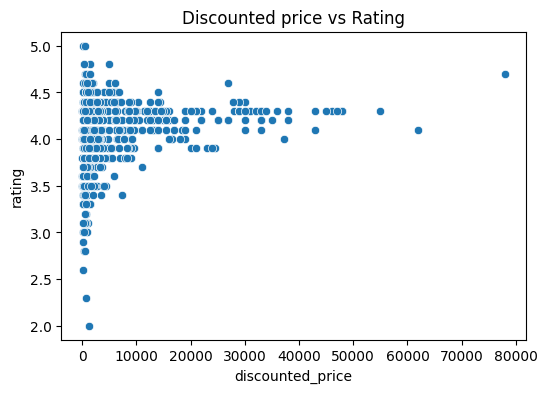

In [ ]:
# Coustomer behaviour after discount
plt.figure(figsize=(6,4))
sns.scatterplot(x='discounted_price', y='rating', data=df)
plt.title('Discounted price vs Rating')
plt.show()

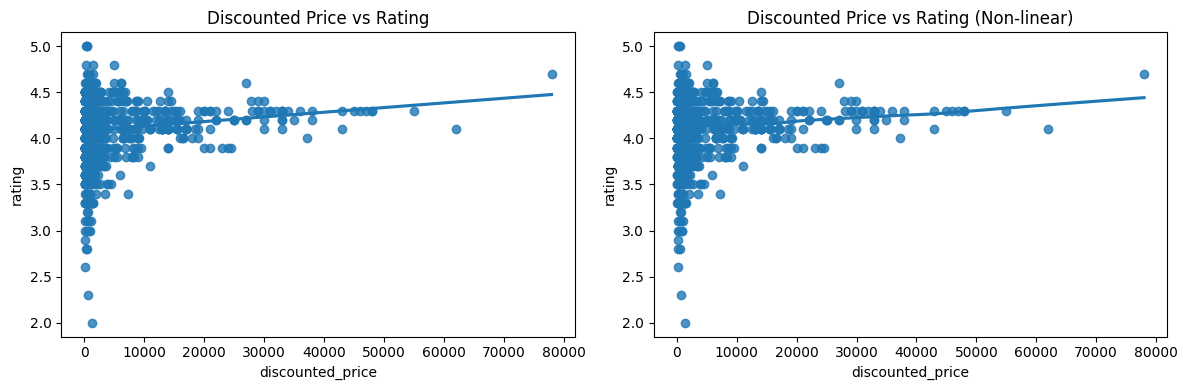

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discounted_price',
            y='rating',
            data=df,
            scatter=True,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discounted Price vs Rating')



sns.regplot(x='discounted_price',
            y='rating',
            data=df,
            lowess=True,
            scatter=True,
            ax=axes[1])

axes[1].set_title('Discounted Price vs Rating (Non-linear)')

plt.tight_layout()
plt.show()


After transformation

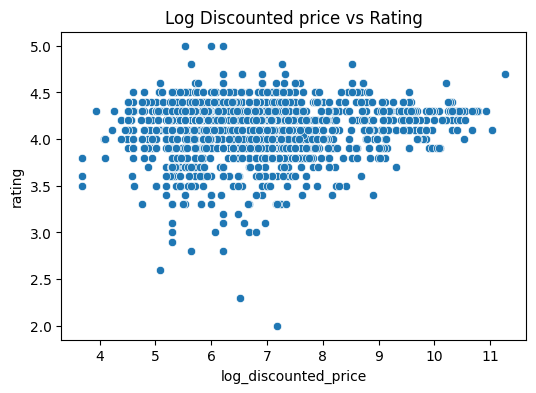

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='log_discounted_price', y='rating', data=df)
plt.title('Log Discounted price vs Rating')
plt.show()

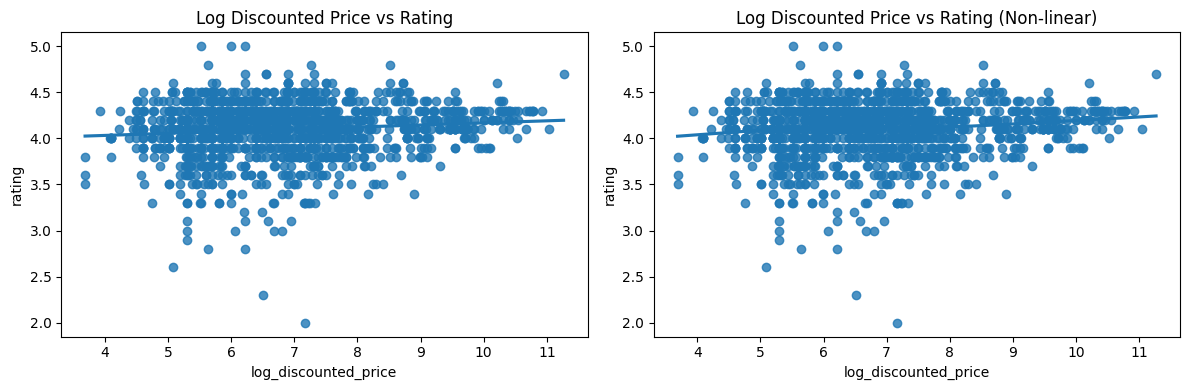

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='log_discounted_price',
            y='rating',
            data=df,
            scatter=True,
            ci=None,
            ax=axes[0])

axes[0].set_title('Log Discounted Price vs Rating')



sns.regplot(x='log_discounted_price',
            y='rating',
            data=df,
            lowess=True,
            scatter=True,
            ax=axes[1])

axes[1].set_title('Log Discounted Price vs Rating (Non-linear)')

plt.tight_layout()
plt.show()


The linear regression line was plotted to understand the overall direction of the relationship between price and rating.

A LOWESS curve was used to explore potential non-linear patterns in the relationship without assuming a straight-line relationship.

*Without dots (Just to see trends without messy data)*

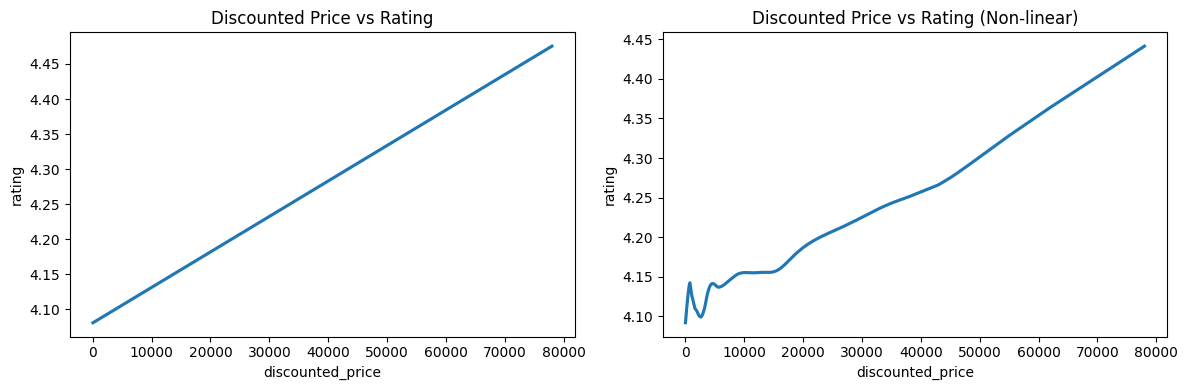

In [ ]:
# Without dots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discounted_price',
            y='rating',
            data=df,
            scatter=False,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discounted Price vs Rating')



sns.regplot(x='discounted_price',
            y='rating',
            data=df,
            lowess=True,
            scatter=False,
            ax=axes[1])

axes[1].set_title('Discounted Price vs Rating (Non-linear)')

plt.tight_layout()
plt.show()


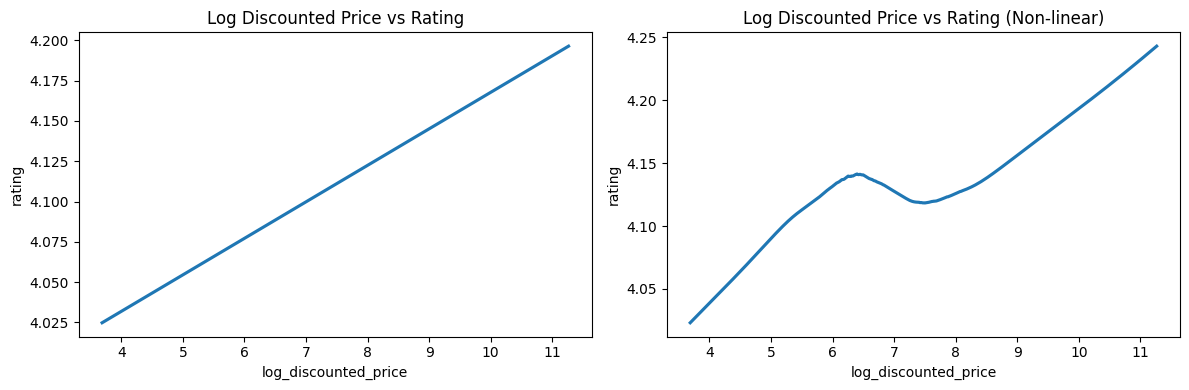

In [ ]:
# Without dots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='log_discounted_price',
            y='rating',
            data=df,
            scatter=False,
            ci=None,
            ax=axes[0])

axes[0].set_title('Log Discounted Price vs Rating')



sns.regplot(x='log_discounted_price',
            y='rating',
            data=df,
            lowess=True,
            scatter=False,
            ax=axes[1])

axes[1].set_title('Log Discounted Price vs Rating (Non-linear)')

plt.tight_layout()
plt.show()


LOWESS (Locally weighted scatterplot smoothing): Is a non-parametric statistical method used to create a smooth, curved line through a scattered dataset. It helps visualize relationships and trends in noisy data.



Both linear and LOWESS (Locally weighted scatterplot smoothing) trend lines were plotted. The linear line provides a general direction of association, while the LOWESS curve reveals the underlying shape of the relationship.

Because the data was skewed and had outliers, I used Spearman correlation.
I plotted both linear and curved trend lines to better understand the pattern between price and rating.

**Key Observation:**

There is a positive relationship between log discounted price and rating.
As price increases, rating tends to increase slightly.

Though the relationship is not perfectly linear there are some low trend in mid price, but after that, the price keeps increasing, and the rating also increases.

Overall the customers are showing postive response to the discounted prices.



2. Discount percentage and ratings

In this case there is no need of transformation since the data was noramll distributed.

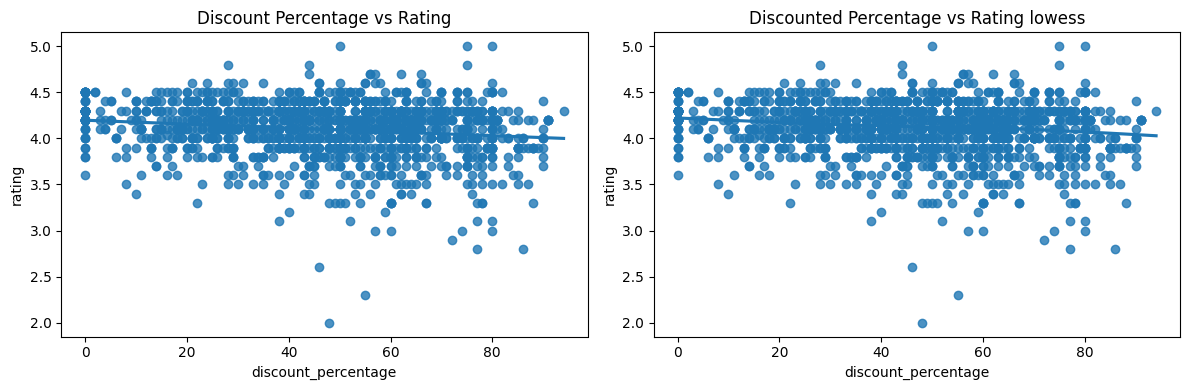

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discount_percentage',
            y='rating',
            data=df,
            scatter=True,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discount Percentage vs Rating')



sns.regplot(x='discount_percentage',
            y='rating',
            data=df,
            lowess=True,
            scatter=True,
            ax=axes[1])

axes[1].set_title('Discounted Percentage vs Rating lowess')

plt.tight_layout()
plt.show()


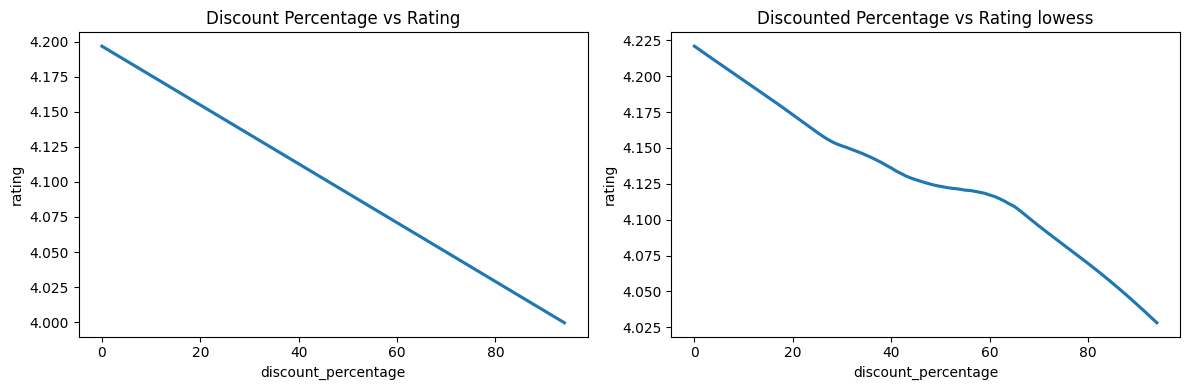

In [ ]:
# Without dots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discount_percentage',
            y='rating',
            data=df,
            scatter=False,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discount Percentage vs Rating')



sns.regplot(x='discount_percentage',
            y='rating',
            data=df,
            lowess=True,
            scatter=False,
            ax=axes[1])

axes[1].set_title('Discounted Percentage vs Rating lowess')

plt.tight_layout()
plt.show()


**Key observation:**

There is **negative** relationship between discount percentage and rataings.

As the discount percentage increases the rating decreases.

This suggests that products with lower ratings may be offered at higher discounts.

3. Discounted price and rating count

Before transformation

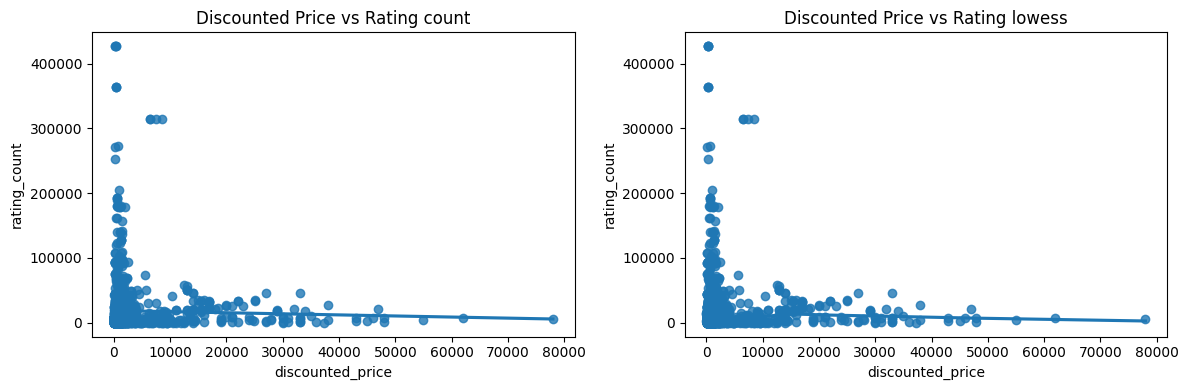

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discounted_price',
            y='rating_count',
            data=df,
            scatter=True,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discounted Price vs Rating count')



sns.regplot(x='discounted_price',
            y='rating_count',
            data=df,
            lowess=True,
            scatter=True,
            ax=axes[1])

axes[1].set_title('Discounted Price vs Rating lowess')

plt.tight_layout()
plt.show()


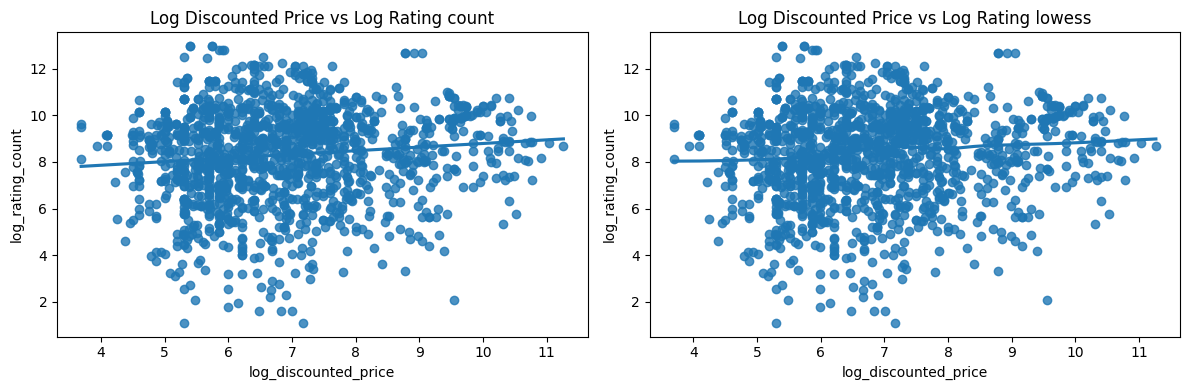

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='log_discounted_price',
            y='log_rating_count',
            data=df,
            scatter=True,
            ci=None,
            ax=axes[0])

axes[0].set_title('Log Discounted Price vs Log Rating count')



sns.regplot(x='log_discounted_price',
            y='log_rating_count',
            data=df,
            lowess=True,
            scatter=True,
            ax=axes[1])

axes[1].set_title('Log Discounted Price vs Log Rating lowess')

plt.tight_layout()
plt.show()


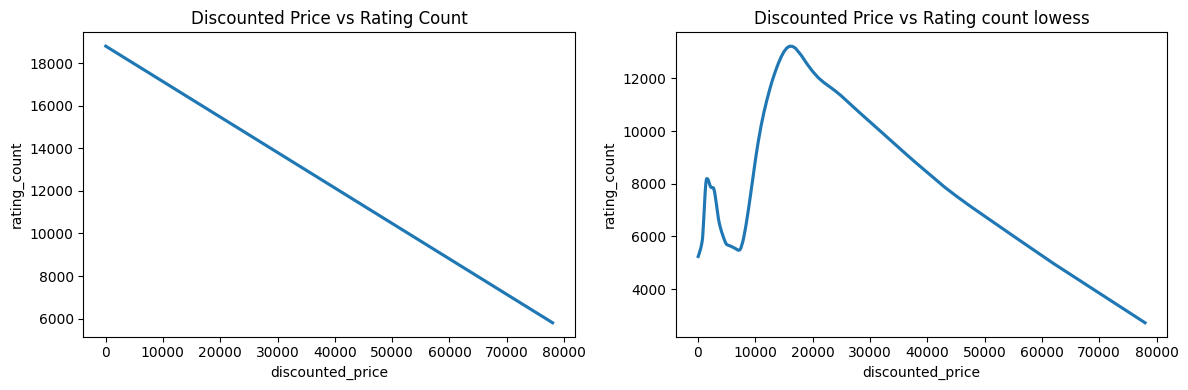

In [ ]:
# Without dots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discounted_price',
            y='rating_count',
            data=df,
            scatter=False,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discounted Price vs Rating Count')



sns.regplot(x='discounted_price',
            y='rating_count',
            data=df,
            lowess=True,
            scatter=False,
            ax=axes[1])

axes[1].set_title('Discounted Price vs Rating count lowess')

plt.tight_layout()
plt.show()


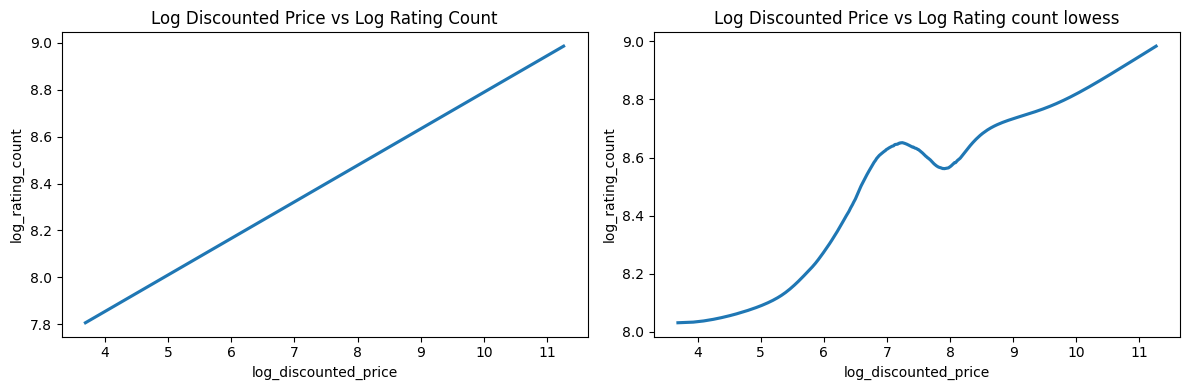

In [ ]:
# Without dots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='log_discounted_price',
            y='log_rating_count',
            data=df,
            scatter=False,
            ci=None,
            ax=axes[0])

axes[0].set_title('Log Discounted Price vs Log Rating Count')



sns.regplot(x='log_discounted_price',
            y='log_rating_count',
            data=df,
            lowess=True,
            scatter=False,
            ax=axes[1])

axes[1].set_title('Log Discounted Price vs Log Rating count lowess')

plt.tight_layout()
plt.show()


**Key Observation:**

Since the data was skewed and was having outliers there is difference in "before" and "after" transformation.

Because linear regression is sensitive to scale and outliers. Which means the relationship depends on how data is distributed.

Before transformation:

Shows relationship in original price scale.

After transformation:

Shows relationship after reducing skewness and extreme influence.

The transformed version is statistically more reliable for pattern interpretation.

**Key note:**

The relationship is weak and the pattern is unstable because of skewness and extreme values.

The relationship is unstable and practically insignificant.


4. Discount percentage and rating count

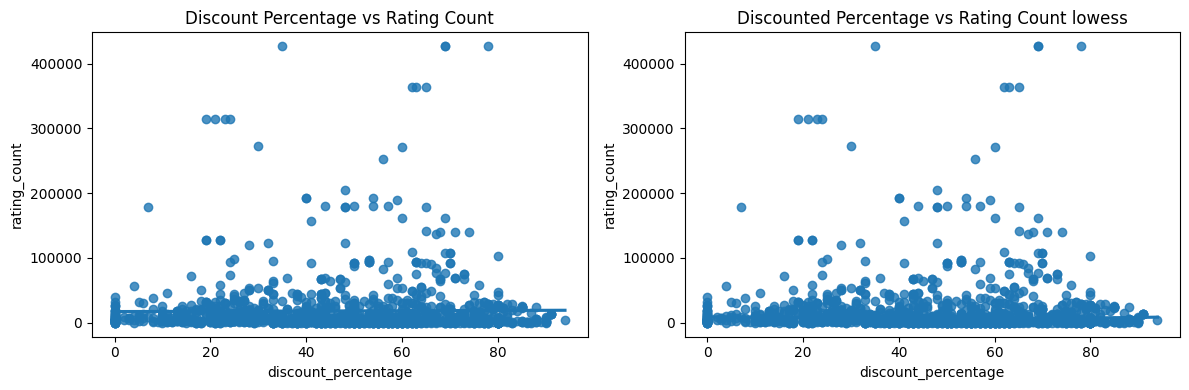

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discount_percentage',
            y='rating_count',
            data=df,
            scatter=True,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discount Percentage vs Rating Count')



sns.regplot(x='discount_percentage',
            y='rating_count',
            data=df,
            lowess=True,
            scatter=True,
            ax=axes[1])

axes[1].set_title('Discounted Percentage vs Rating Count lowess')

plt.tight_layout()
plt.show()


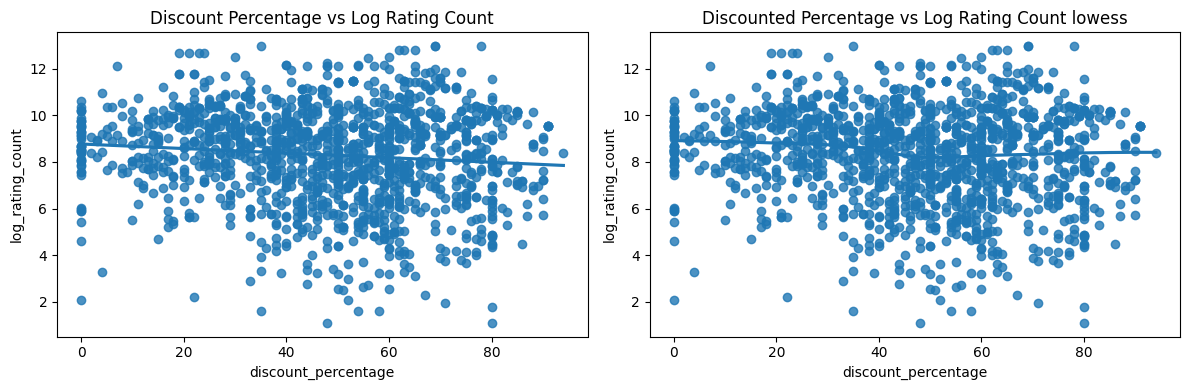

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discount_percentage',
            y='log_rating_count',
            data=df,
            scatter=True,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discount Percentage vs Log Rating Count')



sns.regplot(x='discount_percentage',
            y='log_rating_count',
            data=df,
            lowess=True,
            scatter=True,
            ax=axes[1])

axes[1].set_title('Discounted Percentage vs Log Rating Count lowess')

plt.tight_layout()
plt.show()


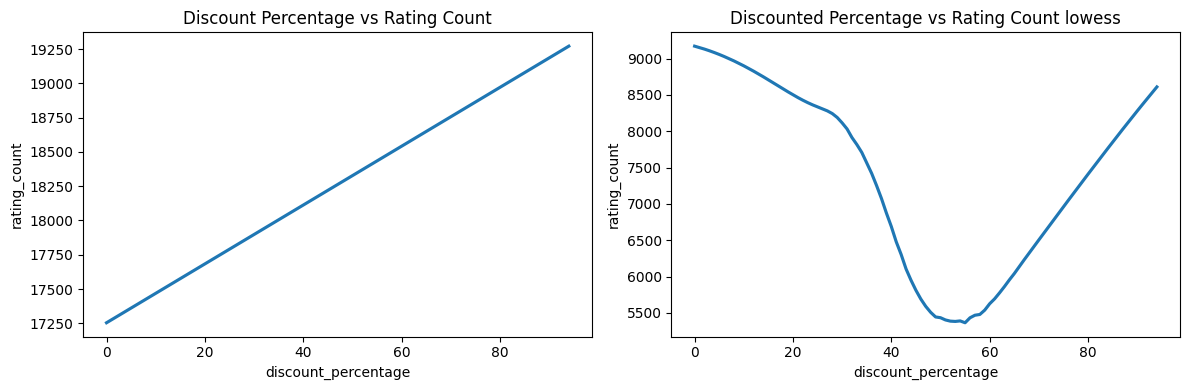

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discount_percentage',
            y='rating_count',
            data=df,
            scatter=False,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discount Percentage vs Rating Count')



sns.regplot(x='discount_percentage',
            y='rating_count',
            data=df,
            lowess=True,
            scatter=False,
            ax=axes[1])

axes[1].set_title('Discounted Percentage vs Rating Count lowess')

plt.tight_layout()
plt.show()


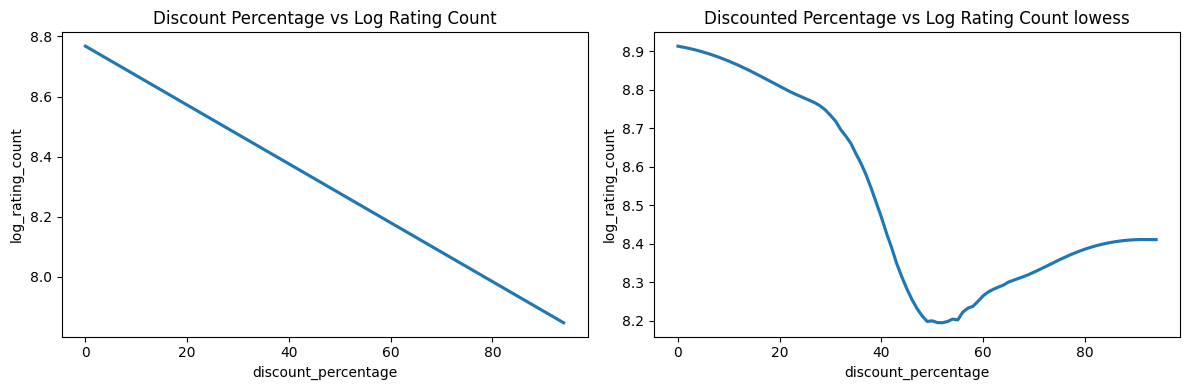

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='discount_percentage',
            y='log_rating_count',
            data=df,
            scatter=False,
            ci=None,
            ax=axes[0])

axes[0].set_title('Discount Percentage vs Log Rating Count')



sns.regplot(x='discount_percentage',
            y='log_rating_count',
            data=df,
            lowess=True,
            scatter=False,
            ax=axes[1])

axes[1].set_title('Discounted Percentage vs Log Rating Count lowess')

plt.tight_layout()
plt.show()


**Key observation:**

The relation seems to be unstable, there is a drastic change (unstable) in linear line which indicate correlation is weak.

After transformation in rating count, the relationship between the attributes appears weak and negative slope occur.
